# Clade C2 results

## Imports etc

In [ ]:
import os
from datetime import datetime
save_res = True

In [ ]:
# Create a folder for results:
if save_res:
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    output_directory = f"res/elfi_res/C2_results/clade_C2_{timestamp}/"
    os.makedirs(output_directory)
    print(f"Created a result directory: {output_directory}")

Created a result directory: res/elfi_res/C2_results/clade_C2_2024-01-11_09-44-14/


In [ ]:
# Load the correct grid parameters:
import importlib
!cp grid_params_clade_C2.py grid_params.py

# Write grid params to file:
with open("grid_params.py", 'r') as f:
    grid_pars = f.read()
    
with open(os.path.join(output_directory, "grid_params.py"), 'w') as f:
    f.write(grid_pars)


In [ ]:
# Import elfi_model.py
 
import elfi_model
importlib.reload(elfi_model)
from elfi_model import *


Loading BSI_functions.py
Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Loading BSI_functions.py
Grid parameters:
Clade: C2
Number of weeks to simulate: 728
Population size: 1000000
Year
2004     0.000390
2005     0.000395
2006     0.000421
2007     8.428780
2008     7.024155
2009     8.686990
2010     3.070367
2011     5.760377
2012    10.741828
2013    21.234113
2014    13.656576
2015    25.312731
2016    15.188393
2017    16.567411
Name: C2, dtype: float64
Model imported
Loading BSI_functions.py
Grid parameters:
Clade: C2
Number of weeks to simulate: 728
Population size: 1000000
Year
2004     0.000390
2005     0.000395
2006     0.000421
2007     8.428780
2008     7.024155
2009     8.686990
2010     3.070367
2011     5.760377
2012    10.741828
2013    21.234113
2014    13.656576
2015    25.312731
2016    15.188393
2017    16.567411
Name: C2, dtype: float64
Model imported


In [ ]:
# For clade C2, specify a prior for lambda (l node in the elfi model)
l.become(elfi.Prior(scipy.stats.uniform, 0, 1, model = m))

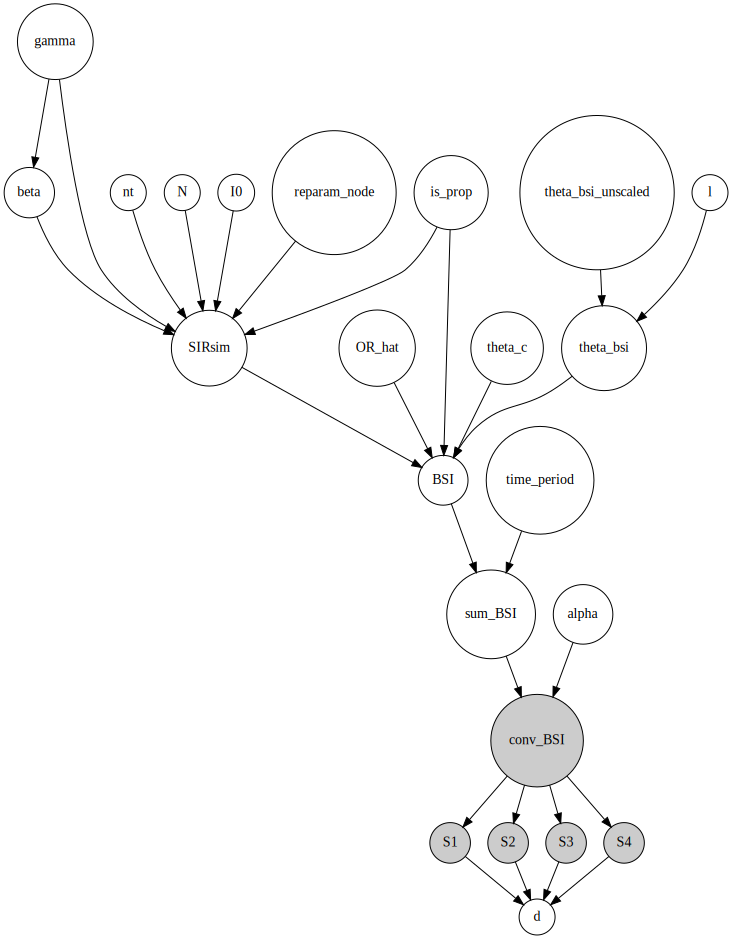

In [ ]:
elfi.draw(m)

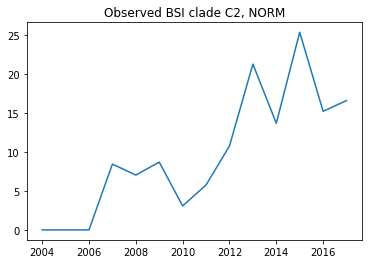

In [ ]:
# Plot the observed data
plt.plot(bsi_obs_data)
plt.title(f"Observed BSI clade {clade}, {obs_data}")
plt.savefig(os.path.join(output_directory, "observed_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
get_OR_hat_pars(or_data, clade = "C2", dataset = "NORM")

(4.0923, 1.5136499999999997)

In [ ]:
OR_hat.generate(10)

4.0923

## Visualizing the prior

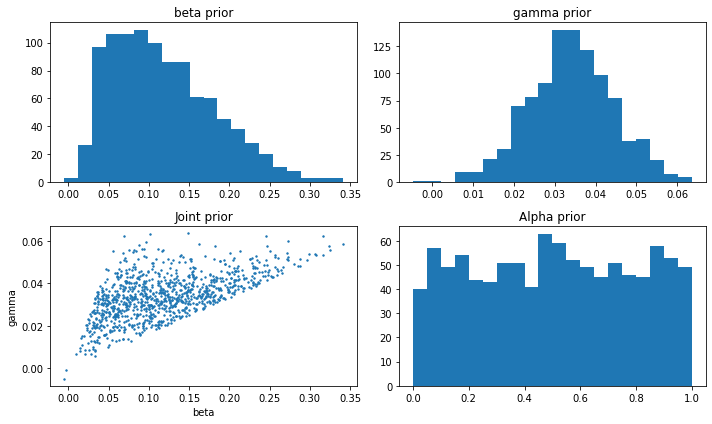

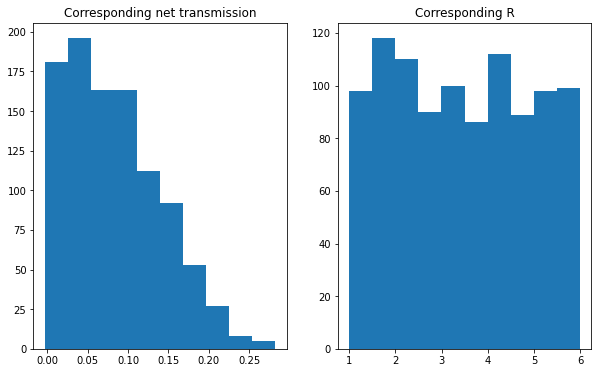

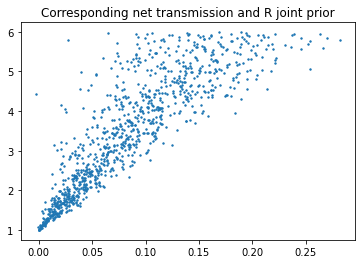

In [ ]:
# Plot the priors
def plot_priors_elfi(par1 = "beta", par2 = "gamma"):
    # Plot priors from the elfi model. Currently supports only (beta, gamma) parametrisation.
    
    prior_sample =  m.generate(1000, outputs = [par1, par2])
    g = prior_sample[par2]
    b = prior_sample[par1]
    a_sample = alpha.generate(1000)


    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(b, bins=20)
    axs[0, 0].set_title(f'{par1} prior')
    axs[0, 1].hist(g, bins=20)
    axs[0, 1].set_title(f'{par2} prior')

    axs[1, 0].scatter(b,g, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel(f'{par1}')
    axs[1, 0].set_ylabel(f'{par2}')

    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, "priors.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

    if not reparam:
        fig, axs = plt.subplots(1, 2, figsize=(10, 6))
        nt_sample = b - g
        R_sample = b/g
        axs[0].hist(nt_sample)
        axs[0].set_title("Corresponding net transmission")

        axs[1].hist(R_sample)
        axs[1].set_title("Corresponding R")
        plt.savefig(os.path.join(output_directory, "corresponding_R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        plt.scatter(nt_sample, R_sample, s=2)
        plt.title("Corresponding net transmission and R joint prior")
        plt.savefig(os.path.join(output_directory, "joint_R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
        plt.show()

if not reparam:    
    plot_priors_elfi()
else:
    net_sample = net_transmission.generate(1000)
    R_sample = R.generate(1000)
    a_sample = alpha.generate(1000)

    #print(R_sample.shape)
    #print(net_sample.shape)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(net_sample, bins=20)
    axs[0, 0].set_title('Net transmission prior')
    axs[0, 1].hist(R_sample, bins=20)
    axs[0, 1].set_title('R prior')
    
    axs[1, 0].scatter(net_sample, R_sample, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Net transmission')
    axs[1, 0].set_ylabel('R')
    
    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    filename = "nt_R_beta_priors.pdf"
    plt.savefig(os.path.join(output_directory, "R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    
    or_sample = OR_hat.generate(1000)
    plt.hist(or_sample)
    plt.title("OR prior")
    plt.savefig(os.path.join(output_directory, "OR_prior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    

    

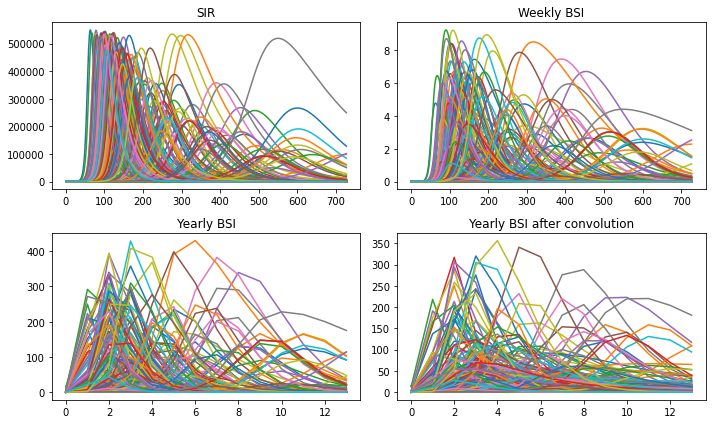

In [ ]:
# Simulations from the prior:
sim_dict = m.generate(batch_size= 200, outputs = ["SIRsim", "BSI", "conv_BSI", "sum_BSI"])
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

axs[0, 0].plot(sim_dict["SIRsim"][1][0:200].T)
axs[0, 0].set_title(f'SIR')
axs[0, 1].plot(sim_dict["BSI"][0:200].T)
axs[0, 1].set_title(f'Weekly BSI')
axs[1, 0].plot(sim_dict["sum_BSI"][0:200].T)
axs[1, 0].set_title(f'Yearly BSI')
axs[1, 1].plot(sim_dict["conv_BSI"][0:200].T)
axs[1, 1].set_title(f'Yearly BSI after convolution')

plt.tight_layout()
plt.savefig(os.path.join(output_directory, "node_draws.pdf"), format="pdf", bbox_inches="tight")
plt.show()


Generating summary figures...
Done!


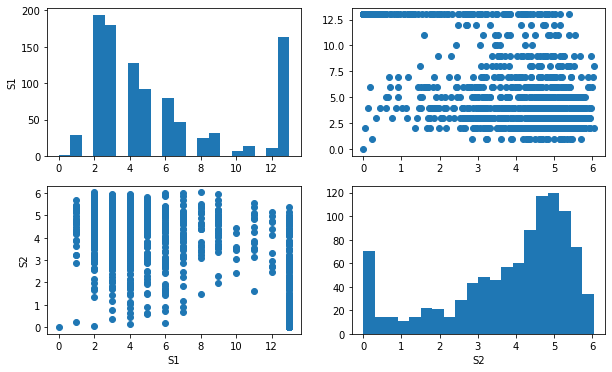

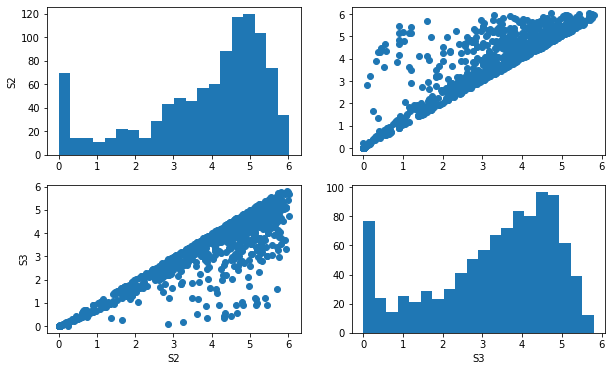

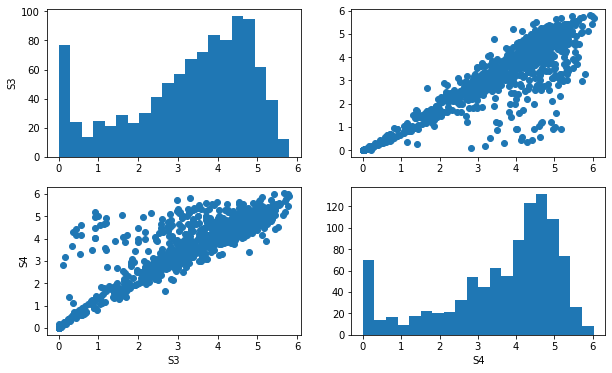

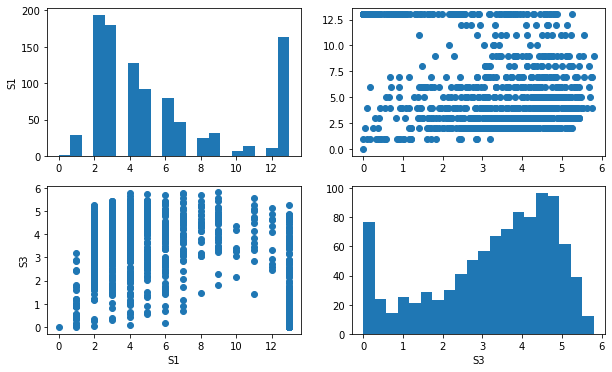

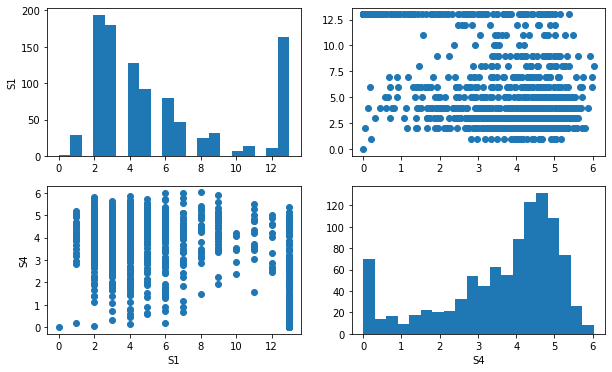

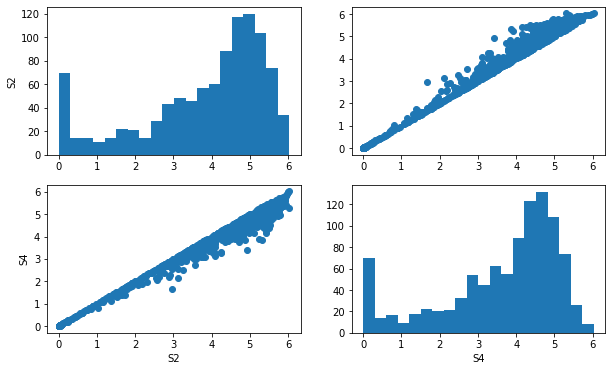

In [ ]:
# Visualize summaries:
ssample = m.generate(1000, outputs = ["S1", "S2", "S3", "S4"])

def get_4x4_summaries(val1, val2, fname = "4x4_plot.pdf"):
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))


    axs[0, 0].hist(ssample[f'{val1}'], bins = 20)
    axs[0, 0].set_ylabel(f'{val1}')
    axs[0, 1].scatter(ssample[f'{val2}'], ssample[f'{val1}'])
    axs[1, 0].scatter(ssample[f'{val1}'], ssample[f'{val2}'])
    axs[1, 0].set_ylabel(f'{val2}')
    axs[1, 0].set_xlabel(f'{val1}')
    #axs[1, 0].set_title(f'S2 and S1')
    axs[1, 1].hist(ssample[f'{val2}'], bins = 20)
    axs[1, 1].set_xlabel(f'{val2}')
    
    plt.savefig(os.path.join(output_directory, fname), format="pdf", bbox_inches="tight")
    #plt.show()
    

print("Generating summary figures...")
get_4x4_summaries("S1", "S2", fname = "4x4_S1_S2_plot.pdf")
get_4x4_summaries("S2", "S3", fname = "4x4_S2_S3_plot.pdf")
get_4x4_summaries("S3", "S4", fname = "4x4_S3_S4_plot.pdf")
#get_4x4_summaries("S4", "S5", fname = "4x4_S4_S5_plot.pdf")
get_4x4_summaries("S1", "S3", fname = "4x4_S1_S3_plot.pdf")
get_4x4_summaries("S1", "S4", fname = "4x4_S1_S4_plot.pdf")
#get_4x4_summaries("S1", "S5", fname = "4x4_S1_S5_plot.pdf")
get_4x4_summaries("S2", "S4", fname = "4x4_S2_S4_plot.pdf")
#get_4x4_summaries("S2", "S5", fname = "4x4_S2_S5_plot.pdf")
#get_4x4_summaries("S3", "S5", fname = "4x4_S3_S5_plot.pdf")

print("Done!")


## Rejection sampling

In [ ]:
rej = elfi.Rejection(d, batch_size=100)
%time result = rej.sample(10000, quantile = 0.01)

Progress [==================================================] 100.0% Complete
CPU times: user 4min 46s, sys: 5.98 s, total: 4min 52s
Wall time: 7min 16s


In [ ]:
#rej = elfi.SMC(d, batch_size=100)
#%time result = rej.sample(1000, thresholds = [1e12, 10000, 1000]) # Problem: lack of logpdf for custom beta prior :)

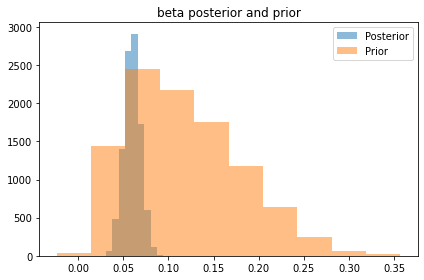

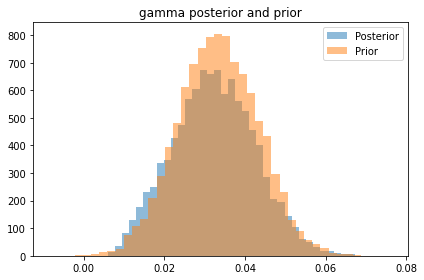

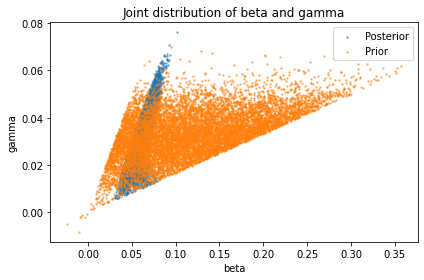

OR hat was not included as an estimated parameter.
Theta_bsi was not included as an estimated parameter.
Alpha was not included as an estimated parameter.


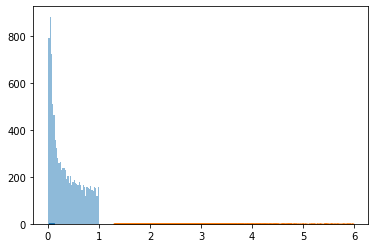

In [ ]:
# Prior and posterior in the same figure
#pars_to_sample = ['OR_hat']
#pars_to_sample = ['theta_bsi']
pars_to_sample = ['alpha']
pars_to_sample = []

if reparam:
    par1 = "net_transmission"
    par2 = "R"
    
else:
    par1 = "beta"
    par2 = "gamma"
    

pars_to_sample.append(par1)
pars_to_sample.append(par2)

if not reparam:
    
    sample = m.generate(10000, pars_to_sample)
    
   

    # Beta or net transmission
    plt.hist(result.samples[par1], alpha = 0.5, label = "Posterior")
    plt.hist(sample[par1], alpha = 0.5, label = "Prior")
    plt.title(f"{par1} posterior and prior")
    plt.legend(loc = "upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"{par1}_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

    # Gamma or R
    plt.hist(result.samples[par2], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample[par2], alpha = 0.5, label = "Prior", bins = 40)
    plt.title(f"{par2} posterior and prior")
    plt.legend(loc = "upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"{par2}_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    
    # Joint prior: beta, gamma
    plt.scatter(result.samples[par1], result.samples[par2], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1], sample[par2], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par1} and {par2}")
    plt.xlabel(f"{par1}")
    plt.ylabel(f"{par2}")
    plt.legend(loc = "upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"joint_{par1}_{par2}_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

    try:
        # OR_hat

        plt.hist(result.samples['OR_hat'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['OR_hat'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("OR_hat posterior and prior")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"OR_hat_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        print("OR hat was not included as an estimated parameter.")

    try:
        # theta_bsi
        plt.hist(result.samples['theta_bsi'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['theta_bsi'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Theta_bsi posterior and prior")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"theta_bsi_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        print("Theta_bsi was not included as an estimated parameter.")
        
    try:
        # OR_hat

        plt.hist(result.samples['alpha'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['alpha'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Alpha posterior and prior")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        print("Alpha was not included as an estimated parameter.")
    
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and OR_hat")
        plt.xlabel(f"{par1}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par1}_OR_hat_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and OR_hat")
        plt.xlabel(f"{par2}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par2}_OR_hat_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        pass
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and alpha")
        plt.xlabel(f"{par1}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par1}_alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and alpha")
        plt.xlabel(f"{par2}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par2}_alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        
        pass
    
    try:
        # Joint prior: par1, theta_bsi

        plt.scatter(result.samples[par1], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and theta_bsi")
        plt.xlabel(f"{par1}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par1}_theta_bsi_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        # Joint prior: par2, theta_bsi

        plt.scatter(result.samples[par2], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and theta_bsi")
        plt.xlabel(f"{par2}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par2}_theta_bsi_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    
    except:
        pass
        
    try:   
        plt.scatter(result.samples[par1]/result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1]/sample[par2], sample['alpha'], alpha = 0.5, s = 2, label = "Prior")
        plt.title(f"Joint distribution of R0 and alpha")
        plt.xlabel("R0")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_R0_alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    except:
        pass

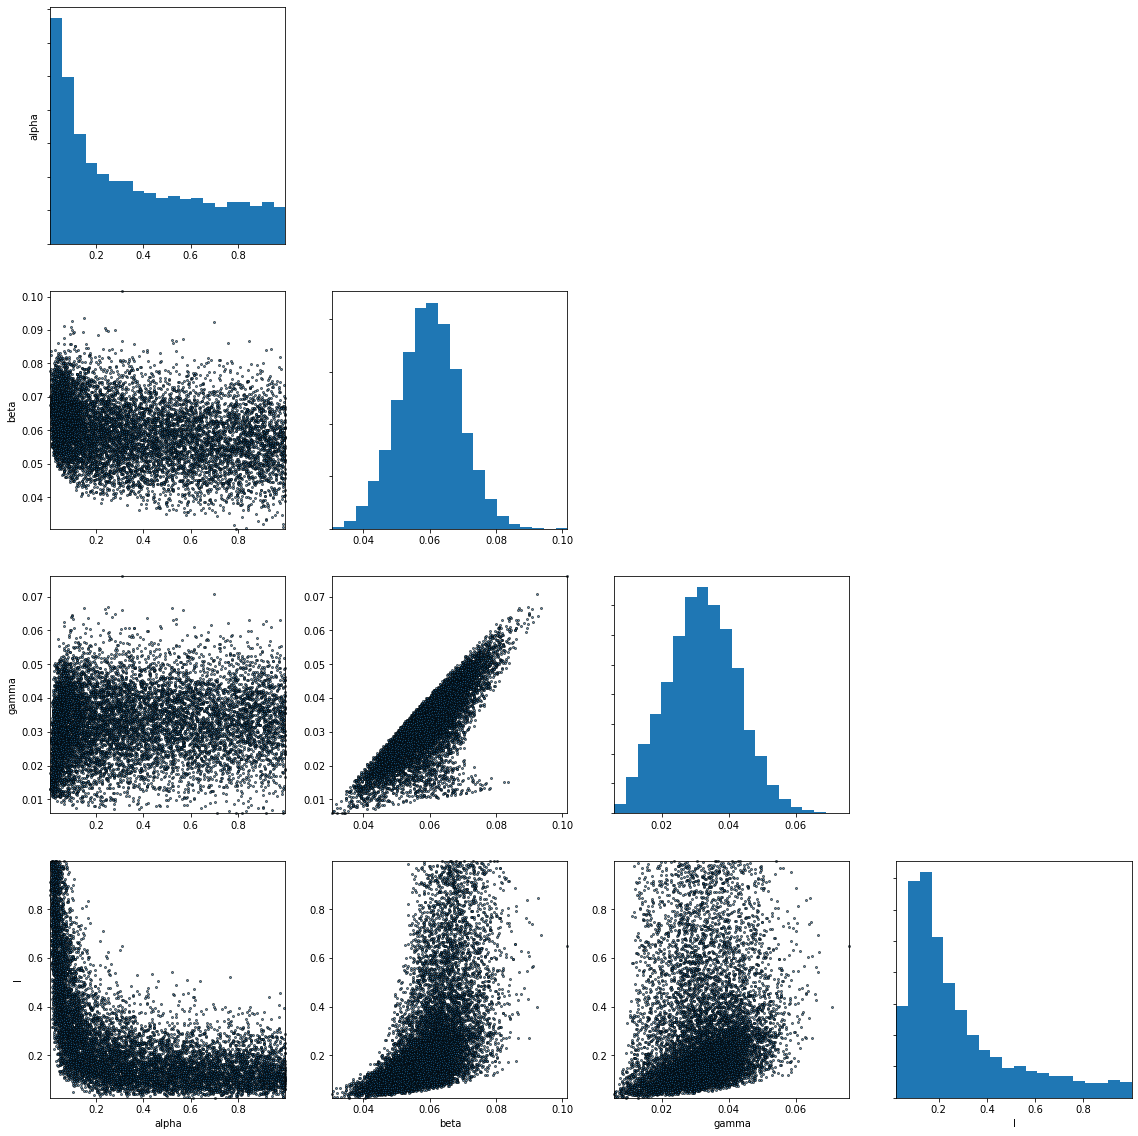

In [ ]:
result.plot_pairs()
plt.savefig(os.path.join(output_directory, "plot_pairs.pdf"))

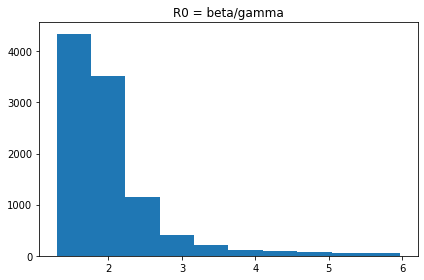

Mean of R: 2.0158835705607077
Median of R: 1.8174512498734934


In [34]:
# Plotting R0

if not reparam:
    R0 = result.samples['beta']/result.samples['gamma']
else:
    R0 = result.samples['R']

plt.hist(R0)
plt.title("R0 = beta/gamma")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"R0_hist.pdf"), format="pdf", bbox_inches="tight")
plt.show()

print(f"Mean of R: {R0.mean()}")
print(f"Median of R: {np.median(R0)}")

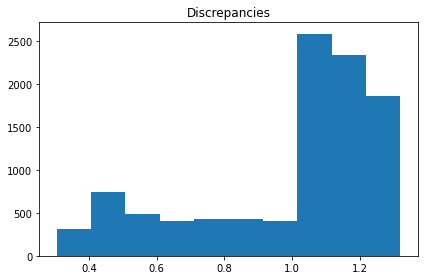

In [35]:
plt.hist(result.discrepancies)
plt.title("Discrepancies")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"discrepancy_hist.pdf"), format="pdf", bbox_inches="tight")
plt.show()

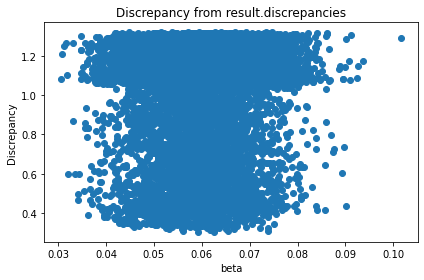

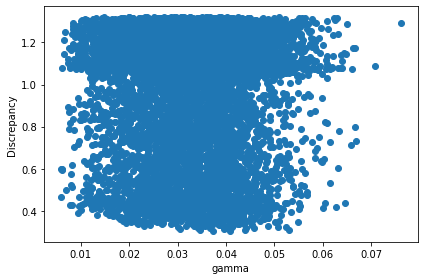

'\nplt.scatter(result.samples[\'OR_hat\'], result.discrepancies)\nplt.xlabel("OR")\nplt.ylabel("Discrepancy")\nplt.show()\n\n'

In [36]:
plt.scatter(result.samples[par1], result.discrepancies)
plt.title("Discrepancy from result.discrepancies")
plt.xlabel(f"{par1}")
plt.ylabel("Discrepancy")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"{par1}_discrepancy_scatter.pdf"), format="pdf", bbox_inches="tight")
plt.show()

plt.scatter(result.samples[par2], result.discrepancies)
plt.xlabel(f"{par2}")
plt.ylabel("Discrepancy")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"{par2}_discrepancy_scatter.pdf"), format="pdf", bbox_inches="tight")
plt.show()

"""
plt.scatter(result.samples['OR_hat'], result.discrepancies)
plt.xlabel("OR")
plt.ylabel("Discrepancy")
plt.show()

"""

(1000, 728)


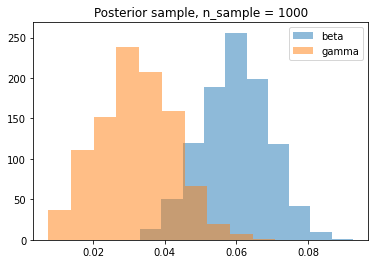

In [73]:
# Updated credible intervals


# First, take a sample from the posterior distribution:
n_sample = 1000
indx = np.random.choice(np.arange(0, len(result.samples[par1])), n_sample) # Ensure that the samples are joint samples by using a same set of indices for all parameters of interest.

par1_post = result.samples[par1][indx]
par2_post = result.samples[par2][indx]
l_post = result.samples["l"][indx]
alpha_post = result.samples["alpha"][indx]


# Start generating from nodes based on these posterior samples:
n_rep = 1 # Should this actually be just one?

SIR_pred = SIRsim.generate(n_rep , with_values = {par1:par1_post, par2:par2_post}) 
print(SIR_pred[0].shape) # (n_sample, T), where T = n_year*52 = 728 (one curve for each posterior sample point)
theta_bsi_post = theta_bsi.generate(n_rep, with_values = {"l":l_post})

BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "OR_hat":OR_hat.generate(1), "theta_bsi": theta_bsi_post})
BSI_yearly_pred = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred})
BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred, "alpha": alpha_post})



plt.hist(par1_post, alpha = 0.5, label = f"{par1}")
plt.hist(par2_post, alpha = 0.5, label = f"{par2}")
plt.legend()
plt.title(f"Posterior sample, n_sample = {n_sample}")
plt.show()

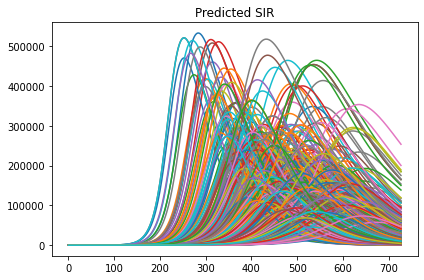

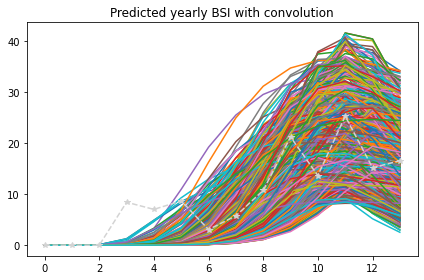

In [86]:
plt.plot(SIR_pred[1].T)
plt.title("Predicted SIR")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"pred_SIR.pdf"), format="pdf", bbox_inches="tight")
plt.show()

plt.plot(BSI_conv_pred.T)
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--', color = "lightgray")
plt.title("Predicted yearly BSI with convolution")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"pred_yearly_conv_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()

(14,)
(2, 14)


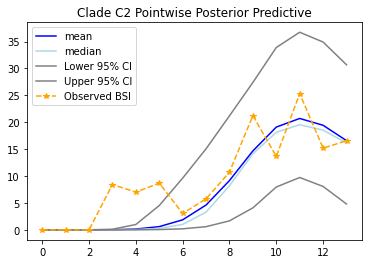

In [96]:
# Pointwise credible intervals and expected values: result should be a (1, 14) vector for each (lower, upper, mean/median)

expected_value = np.mean(BSI_conv_pred, axis = 0)
med = np.median(BSI_conv_pred, axis = 0)

cis = np.percentile(BSI_conv_pred, [(100-ci)/2, 100 - (100-ci)/2], axis = 0)
print(expected_value.shape)
print(cis.shape)
plt.plot(expected_value, label = "mean", color = "blue")
plt.plot(med, label = "median", color = "lightblue")
plt.plot(cis[0,:], label = f"Lower {ci}% CI", color = "gray")
plt.plot(cis[1,:], label = f"Upper {ci}% CI", color = "gray")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--', color = "orange")
plt.legend()
plt.title("Clade C2 Pointwise Posterior Predictive")
plt.show()

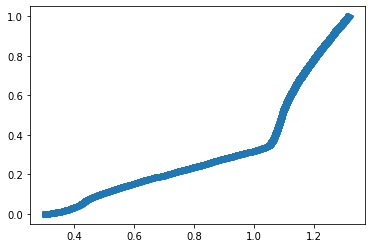

In [37]:
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/float(len(xs))
    return xs, ys

xs, ys = ecdf(result.discrepancies)
plt.plot(xs, ys, label="handwritten", marker=">", markerfacecolor='none')

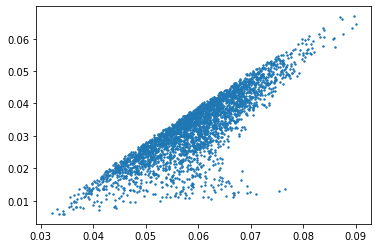

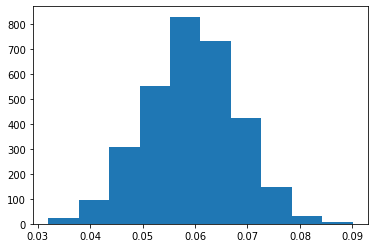

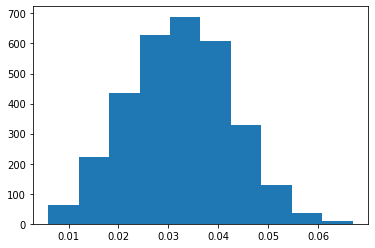

In [40]:
eps = 1.0
p1 = result.samples[par1][np.where(result.discrepancies < eps)]
p2 = result.samples[par2][np.where(result.discrepancies < eps)]

plt.scatter(p1, p2, s = 2)
plt.show()

plt.hist(p1)
plt.show()

plt.hist(p2)
plt.show()

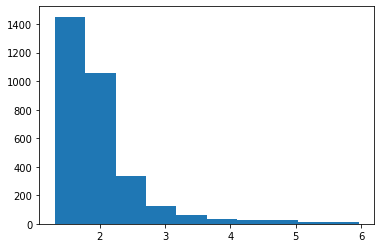

R0 mean: 2.0060661658520447
R0 median: 1.8062484439474655


In [41]:
if not reparam:
    plt.hist(p1/p2)
    plt.show()
    print(f"R0 mean: {np.mean(p1/p2)}")
    print(f"R0 median: {np.median(p1/p2)}")
else:
    plt.hist(p2)
    plt.show()
    print(f"R mean: {np.mean(p2)}")
    print(f"R median: {np.median(p2)}")
    
    